In [2]:
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error


In [ ]:
#----------#
#LOAD DATA 
#----------#
data = pd.read_csv("/workspaces/Elevvo_Internship_Tasks/Data/StudentPerformanceFactors.csv")
print(data.head(5))

   Hours_Studied  Attendance Parental_Involvement Access_to_Resources  \
0             23          84                  Low                High   
1             19          64                  Low              Medium   
2             24          98               Medium              Medium   
3             29          89                  Low              Medium   
4             19          92               Medium              Medium   

  Extracurricular_Activities  Sleep_Hours  Previous_Scores Motivation_Level  \
0                         No            7               73              Low   
1                         No            8               59              Low   
2                        Yes            7               91           Medium   
3                        Yes            8               98           Medium   
4                        Yes            6               65           Medium   

  Internet_Access  Tutoring_Sessions Family_Income Teacher_Quality  \
0             Ye

In [ ]:
#-----------------------#
#CHECKING NULL VALUES
#-----------------------#

print(data.isnull().sum())

Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64


In [ ]:
#----------------------------#
#REMOVING NULL VALUES
#----------------------------#
df = data.dropna(subset=['Teacher_Quality','Parental_Education_Level','Distance_from_Home'])
print(df.isnull().sum())

Hours_Studied                 0
Attendance                    0
Parental_Involvement          0
Access_to_Resources           0
Extracurricular_Activities    0
Sleep_Hours                   0
Previous_Scores               0
Motivation_Level              0
Internet_Access               0
Tutoring_Sessions             0
Family_Income                 0
Teacher_Quality               0
School_Type                   0
Peer_Influence                0
Physical_Activity             0
Learning_Disabilities         0
Parental_Education_Level      0
Distance_from_Home            0
Gender                        0
Exam_Score                    0
dtype: int64


In [ ]:
#---------------------#
#DATA PRE-PROCESSING
#---------------------#

cdf = df[['Hours_Studied','Sleep_Hours','Access_to_Resources','Exam_Score']]
print(cdf.sample(2))

X = cdf.Hours_Studied.to_numpy()
print(X.shape)
y = cdf.Exam_Score.to_numpy()

      Hours_Studied  Sleep_Hours Access_to_Resources  Exam_Score
1868             13            7              Medium          66
62               13            9                High          68
(6378,)


In [ ]:
#---------------------------------------#
# SPLITTING DATA INTO TRAINS & TEST SETS 
#---------------------------------------#
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=45)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(5102,)
(1276,)
(5102,)
(1276,)


In [ ]:
#-----------------------------------#
# BUILDING AND TRAINING LINEAR MODEL 
#-----------------------------------#
regressor = LinearRegression()
regressor.fit(X_train.reshape(-1,1), y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [9]:
#print coeffients
print("Slope (m):", regressor.coef_[0])
print("Intercept (c):", regressor.intercept_)

Slope (m): 0.2945471468519161
Intercept (c): 61.377335495601535


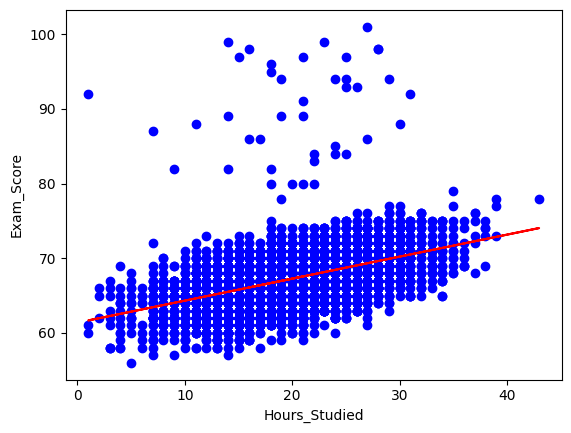

In [ ]:
#-------------------------#
# VISUALIZE MODEL OUTPUT 
#-------------------------#

plt.scatter(X_train, y_train, color = 'blue')
plt.plot(X_train, regressor.coef_ * X_train + regressor.intercept_, 'r')
plt.xlabel('Hours_Studied')
plt.ylabel('Exam_Score')
plt.show()


In [ ]:
#------------------------------#
# PREDICTION ON A TEST SET
#------------------------------#

y_pred = regressor.predict(X_test.reshape(-1,1))
print("Predicted scores:", y_pred)


Predicted scores: [65.50099555 69.03556131 61.96642979 ... 66.67918414 67.85737273
 66.67918414]


In [ ]:
#-----------------------#
# MODEL EVALUATION
#-----------------------#

print("R² Score:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))


R² Score: 0.2111187052303639
RMSE: 3.3181976135434468


In [13]:
#-------------------------------------#
# MAKING A PREDICTION ON A NEW STUDENT
#-------------------------------------#
new_hours = np.array([[7.5]])
predicted_score = regressor.predict(new_hours)
print(f"Predicted score for 7.5 hours of study: {predicted_score[0]:.2f}")

Predicted score for 7.5 hours of study: 63.59
